# Baseline Model: Naive Bayes + TF-IDF

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuration
RANDOM_SEED = 42
N_FOLDS = 5
np.random.seed(RANDOM_SEED)

## 1. Load Data

In [2]:
# Load train and test data
DATA_DIR = Path('../processed_data')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Train set: {len(train_df):,} reviews")
print(f"Test set: {len(test_df):,} reviews")
print("\nTrain sentiment distribution:")
print(train_df['voted_up'].value_counts(normalize=True))

Train set: 34,481 reviews
Test set: 6,086 reviews

Train sentiment distribution:
voted_up
True     0.500044
False    0.499956
Name: proportion, dtype: float64


In [3]:
# Prepare features and labels
X_train = train_df['processed_text'].fillna('')
y_train = train_df['voted_up'].astype(int)

X_test = test_df['processed_text'].fillna('')
y_test = test_df['voted_up'].astype(int)

# Create stratification key for K-Fold
stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

print(f"Features: {len(X_train):,} train, {len(X_test):,} test")
print(f"Labels: {y_train.value_counts().to_dict()}")

Features: 34,481 train, 6,086 test
Labels: {1: 17242, 0: 17239}


## 2. Build Baseline Pipeline

In [4]:
# Create TF-IDF + Naive Bayes pipeline
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('clf', MultinomialNB(alpha=1.0))
])

print(baseline_pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=10000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', MultinomialNB())])


## 3. K-Fold Cross-Validation

In [5]:
# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Store metrics for each fold
fold_metrics = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

print(f"Running {N_FOLDS}-Fold Cross-Validation")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
    # Split data
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Train
    baseline_pipeline.fit(X_fold_train, y_fold_train)
    
    # Predict
    y_pred = baseline_pipeline.predict(X_fold_val)
    
    # Calculate metrics
    acc = accuracy_score(y_fold_val, y_pred)
    prec = precision_score(y_fold_val, y_pred)
    rec = recall_score(y_fold_val, y_pred)
    f1 = f1_score(y_fold_val, y_pred)
    
    # Store
    fold_metrics['fold'].append(fold + 1)
    fold_metrics['accuracy'].append(acc)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)
    
    print(f"Fold {fold + 1}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(fold_metrics)

Running 5-Fold Cross-Validation
Fold 1: Accuracy=0.8589, Precision=0.8736, Recall=0.8394, F1=0.8561
Fold 2: Accuracy=0.8593, Precision=0.8723, Recall=0.8420, F1=0.8569
Fold 3: Accuracy=0.8638, Precision=0.8854, Recall=0.8359, F1=0.8600
Fold 4: Accuracy=0.8580, Precision=0.8847, Recall=0.8234, F1=0.8529
Fold 5: Accuracy=0.8572, Precision=0.8769, Recall=0.8309, F1=0.8533


In [6]:
# Summary statistics
print("CROSS-VALIDATION RESULTS SUMMARY")
print(f"\n{'Metric':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    print(f"{metric.capitalize():<12} {mean:>10.4f} {std:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

print(f"\nMacro F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")

CROSS-VALIDATION RESULTS SUMMARY

Metric             Mean        Std        Min        Max
Accuracy         0.8595     0.0026     0.8572     0.8638
Precision        0.8786     0.0062     0.8723     0.8854
Recall           0.8343     0.0074     0.8234     0.8420
F1               0.8558     0.0029     0.8529     0.8600

Macro F1 Score: 0.8558 ± 0.0029


## 4. Final Evaluation on Test Set

In [7]:
# Train on full training set
print("Training final model on full training set...")
baseline_pipeline.fit(X_train, y_train)

# Predict on test set
y_test_pred = baseline_pipeline.predict(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTEST SET RESULTS")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

Training final model on full training set...

TEST SET RESULTS
Accuracy:  0.8597
Precision: 0.8802
Recall:    0.8327
F1 Score:  0.8558


In [8]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.86      3043
    Positive       0.88      0.83      0.86      3043

    accuracy                           0.86      6086
   macro avg       0.86      0.86      0.86      6086
weighted avg       0.86      0.86      0.86      6086



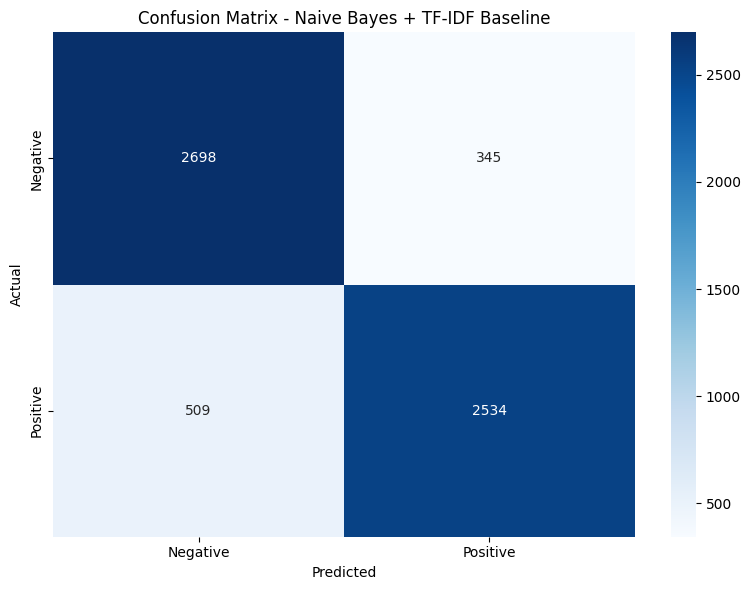


True Negatives:  2,698
False Positives: 345
False Negatives: 509
True Positives:  2,534


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes + TF-IDF Baseline')
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

## 5. Performance by Genre

In [10]:
# Analyze performance by genre
test_df['predicted'] = y_test_pred
test_df['correct'] = (test_df['voted_up'].astype(int) == test_df['predicted'])

genre_performance = test_df.groupby('primary_genre').agg({
    'correct': ['sum', 'count', 'mean']
}).round(4)
genre_performance.columns = ['correct', 'total', 'accuracy']
genre_performance = genre_performance.sort_values('accuracy', ascending=False)

print("PERFORMANCE BY GENRE")

print(genre_performance.to_string())

PERFORMANCE BY GENRE
                        correct  total  accuracy
primary_genre                                   
sports                      270    292    0.9247
puzzle_matching             505    555    0.9099
exploration_open_world      656    748    0.8770
rpg_action                  596    688    0.8663
anime                       290    337    0.8605
visual_novel                 67     78    0.8590
science_fiction             826    963    0.8577
casual                      529    626    0.8450
action_fps                  602    719    0.8373
survival                    565    680    0.8309
horror                      238    289    0.8235
hidden_object                88    111    0.7928


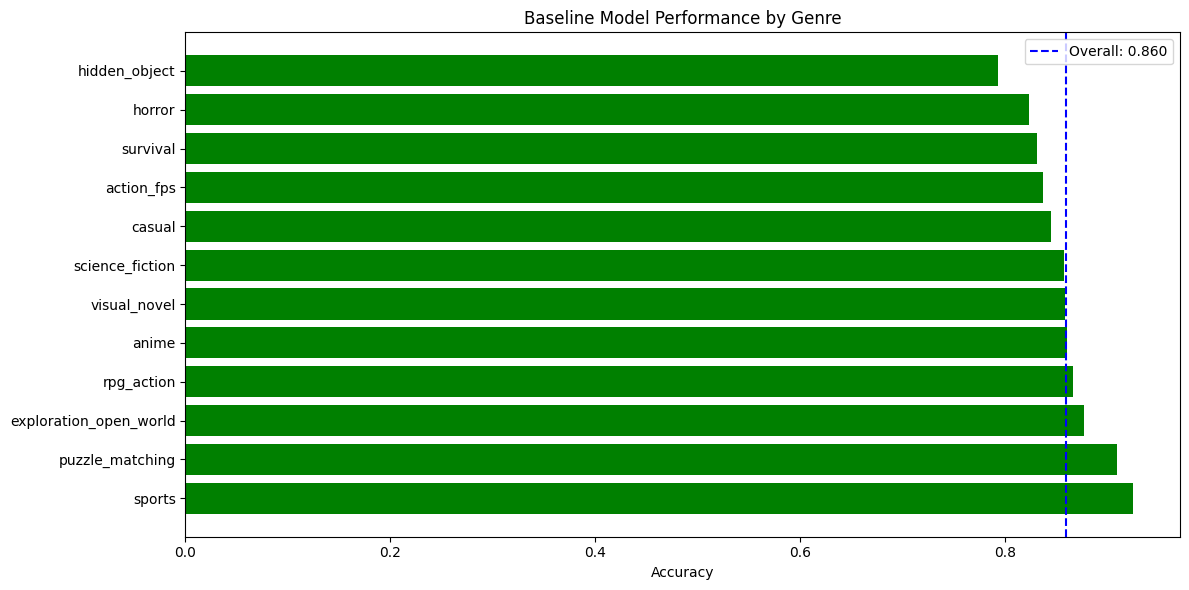

In [11]:
# Visualize genre performance
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 0.75 else 'orange' if x >= 0.65 else 'red' 
          for x in genre_performance['accuracy']]
plt.barh(genre_performance.index, genre_performance['accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Baseline Model Performance by Genre')
plt.axvline(x=test_accuracy, color='blue', linestyle='--', label=f'Overall: {test_accuracy:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance (Top Words)

In [12]:
# Get feature names and log probabilities
tfidf = baseline_pipeline.named_steps['tfidf']
clf = baseline_pipeline.named_steps['clf']

feature_names = tfidf.get_feature_names_out()
log_probs = clf.feature_log_prob_

# Calculate log probability ratio (positive - negative)
log_ratio = log_probs[1] - log_probs[0]

# Top positive and negative words
n_top = 20
top_positive_idx = log_ratio.argsort()[-n_top:][::-1]
top_negative_idx = log_ratio.argsort()[:n_top]

print("TOP 20 WORDS INDICATING POSITIVE SENTIMENT")

for idx in top_positive_idx:
    print(f"  {feature_names[idx]:<25} (log ratio: {log_ratio[idx]:.3f})")

print("\nTOP 20 WORDS INDICATING NEGATIVE SENTIMENT")

for idx in top_negative_idx:
    print(f"  {feature_names[idx]:<25} (log ratio: {log_ratio[idx]:.3f})")

TOP 20 WORDS INDICATING POSITIVE SENTIMENT
  definitely worth          (log ratio: 2.874)
  well worth                (log ratio: 2.839)
  short but                 (log ratio: 2.742)
  definitely recommend      (log ratio: 2.689)
  can wait                  (log ratio: 2.681)
  highly recommended        (log ratio: 2.676)
  highly recommend          (log ratio: 2.617)
  best hockey               (log ratio: 2.594)
  worth every               (log ratio: 2.542)
  10 10                     (log ratio: 2.507)
  only complaint            (log ratio: 2.442)
  addictive                 (log ratio: 2.381)
  cant wait                 (log ratio: 2.357)
  only downside             (log ratio: 2.316)
  addicting                 (log ratio: 2.298)
  still holds               (log ratio: 2.296)
  holds up                  (log ratio: 2.277)
  hockey                    (log ratio: 2.248)
  must play                 (log ratio: 2.235)
  downside is               (log ratio: 2.224)

TOP 20 WORDS IND

## 7. Summary & Save Results

In [13]:
# Summary
print("BASELINE MODEL SUMMARY")
print("\nModel: Multinomial Naive Bayes + TF-IDF")
print("Vectorizer: max_features=10000, ngram_range=(1,2)")
print(f"\nCross-Validation ({N_FOLDS}-Fold):")
print(f"  F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")
print("\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

BASELINE MODEL SUMMARY

Model: Multinomial Naive Bayes + TF-IDF
Vectorizer: max_features=10000, ngram_range=(1,2)

Cross-Validation (5-Fold):
  F1 Score: 0.8558 ± 0.0029

Test Set Performance:
  Accuracy:  0.8597
  Precision: 0.8802
  Recall:    0.8327
  F1 Score:  0.8558


In [14]:
# Save results to JSON for comparison with other models
import json

results = {
    'model_name': 'Naive Bayes + TF-IDF (Baseline)',
    'cross_validation': {
        'n_folds': N_FOLDS,
        'accuracy_mean': float(results_df['accuracy'].mean()),
        'accuracy_std': float(results_df['accuracy'].std()),
        'f1_mean': float(results_df['f1'].mean()),
        'f1_std': float(results_df['f1'].std()),
        'precision_mean': float(results_df['precision'].mean()),
        'recall_mean': float(results_df['recall'].mean())
    },
    'test_set': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1)
    }
}

# Save results
results_path = '../results/baseline_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")

Results saved to ../results/baseline_results.json


In [16]:
# Save model pipeline
joblib.dump(baseline_pipeline, '../models/baseline.joblib')

['../models/baseline.joblib']